# Frontier: PLAN 08 Step 13 actual high-escaping charts

This notebook isolates the remaining obstruction in Step 13 after the abstract overlap-comparison theorem was formalized.

The comparison frontier is now recorded separately in `notebooks/plan08_step13_overlap_comparison_frontier.ipynb`. The present notebook focuses on the missing existence-and-packaging problem for the **actual** high-escaping chart chains.


## Current status

Already formalized:

- the canonical arbitrarily-high escaping chains,
- the abstract uniqueness/comparison theorem for logarithm branches on connected chart chains,
- the direct open-overlap bridge from local logarithm equality to trivial monodromy, through `ZeroFreeChartRootBranchData.rootBranch_eqOn_of_logBranch_eqOn`, `BasinLoopChartOverlapStep.multiplier_eq_one_of_eqOn`, `ChartChainLocalLogsEventuallyEqAtOverlaps.of_open_eqOn`, and `BasinLoopChartChain.monodromyProduct_eq_one_of_open_eqOn`,
- the high-level wrapper interfaces `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`, `HighEscapingActualChartChainsLocalLogsRestrictGlobalData`, and `HighEscapingActualChartChainsProductComparisonData`.

This sharpens the proof status:

- the previous universal global-log theorem candidate is **false as stated** for arbitrary basin loops;
- the weakened local chart-chain theorem is now formalized at the abstract level;
- no numerical counterexample is currently known to the weakened theorem;
- the genuine remaining target is to construct, for the actual high-escaping chains, the domains $U_j$, overlap neighborhoods $V_j$, and actual branches $b_j, \xi_j$ that supply `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`;
- the one-global-log route survives only as a special case when the high-level image has zero winding around $0$.


## Numerical counterexample to the discarded strong theorem

Consider the exterior basin loop
$$
\gamma_R(t) = R e^{2\pi i t}, \qquad R = 5.
$$
For $c = 2$, this loop stays entirely in the basin and entirely in the outside-open region. Numerically, using an $8$-term truncation of $\text{logSeriesBottcherApprox}(2,\cdot)$, its image is a small deformation of the same circle and still winds once around $0$.

If the discarded strong theorem were true for every loop, then for some $K \ge N_0$ the high-level image curve
$$
A_K(t) = \text{logSeriesBottcherApprox}\bigl(2, f_2^K(\gamma_R(t))\bigr)
$$
would lie in a simply connected zero-free neighborhood
$$
A_K([0,1]) \subset V \subset \mathbf{C} \setminus \{0\}
$$
carrying one holomorphic logarithm. That would force the winding number of $A_K$ around $0$ to be $0$. The computation below shows the opposite behavior numerically: the winding is already about $1$ at level $0$, and under the squaring/conjugacy picture it doubles to $2,4,8$ at the next levels.


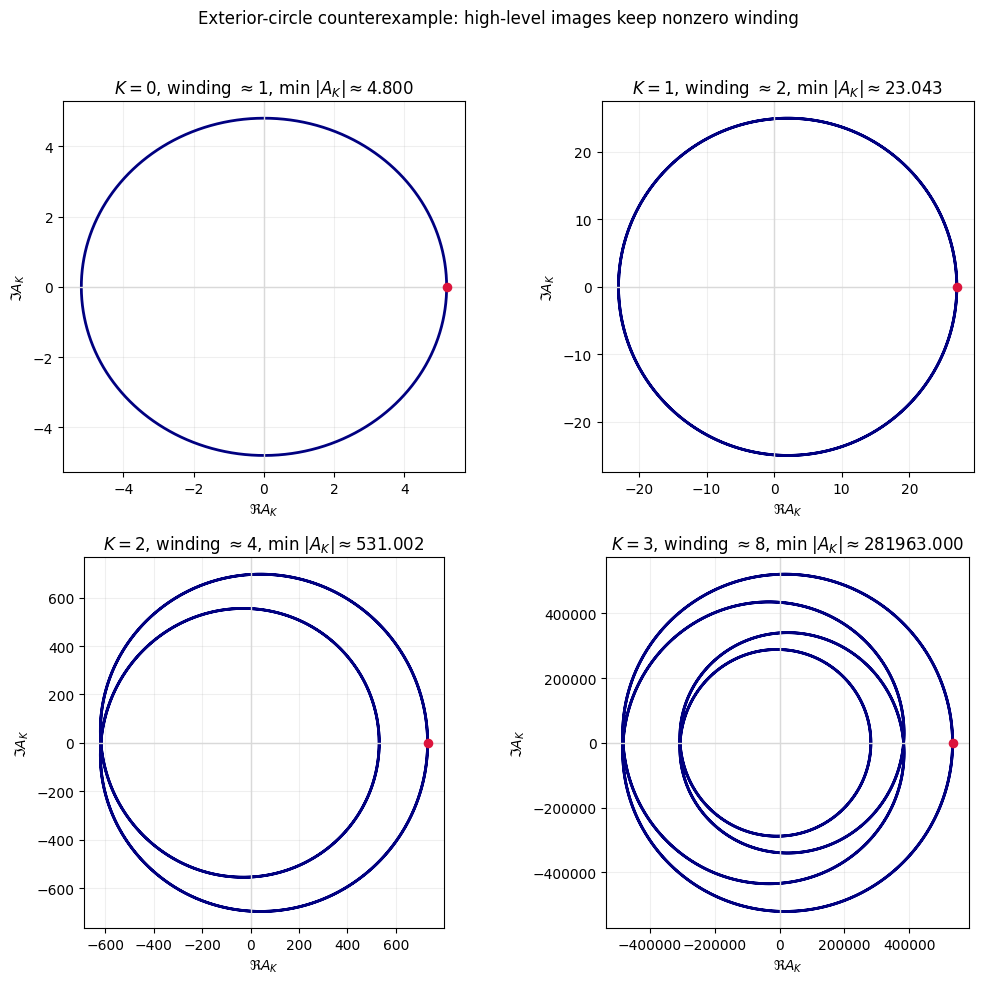

Level-0 diagnostics for finite log-series Bottcher approximation:
  winding(phi(gamma_R)) ≈ 1.0
  min |phi(gamma_R)| = 4.8003622890755935
  max |phi(gamma_R)/gamma_R - 1| = 0.040064321868088094
  min Re(phi(gamma_R)/gamma_R) = 0.9600724578151187

K=0: winding ≈ 1, min |A_K| ≈ 4.8003622890755935
K=1: winding ≈ 2, min |A_K| ≈ 23.043478106379073
K=2: winding ≈ 4, min |A_K| ≈ 531.0018832391717
K=3: winding ≈ 8, min |A_K| ≈ 281963.0000035469


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

c = 2.0 + 0.0j
R = 5.0
terms = 8

def f(z):
    return z * z + c

def iterate_f(z, N):
    out = np.array(z, dtype=np.complex128)
    for _ in range(N):
        out = out * out + c
    return out

def near_one_log_correction(z, N):
    zpow1 = z ** (2 ** (N + 1))
    zpow0 = z ** (2 ** N)
    den = (iterate_f(z, N) / zpow0) ** 2
    return (1 / (2 ** (N + 1))) * np.log(1 + (c / zpow1) / den)

def finite_phi(z, terms=8):
    s = np.zeros_like(z, dtype=np.complex128)
    for N in range(terms):
        s += near_one_log_correction(z, N)
    return z * np.exp(s)

def winding(values):
    ang = np.unwrap(np.angle(values))
    return (ang[-1] - ang[0]) / (2 * np.pi)

ts = np.linspace(0.0, 1.0, 4097)
zs = R * np.exp(2j * np.pi * ts)
phi_vals = finite_phi(zs, terms=terms)
ratio = phi_vals / zs
high_level_vals = [phi_vals ** (2 ** K) for K in range(4)]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 10.0))
for ax, K, vals in zip(axes.flat, range(4), high_level_vals):
    ax.plot(vals.real, vals.imag, color='navy', lw=2)
    ax.scatter([vals[0].real], [vals[0].imag], color='crimson', s=35, zorder=3)
    ax.axhline(0.0, color='0.85', lw=1)
    ax.axvline(0.0, color='0.85', lw=1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
    ax.set_title(
        f'$K={K}$, winding $\\approx {winding(vals):.0f}$, '
        f'min $|A_K| \\approx {np.min(np.abs(vals)):.3f}$'
    )
    ax.set_xlabel(r'$\Re A_K$')
    ax.set_ylabel(r'$\Im A_K$')
fig.suptitle(r'Exterior-circle counterexample: high-level images keep nonzero winding', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Level-0 diagnostics for finite log-series Bottcher approximation:')
print('  winding(phi(gamma_R)) ≈', winding(phi_vals))
print('  min |phi(gamma_R)| =', np.min(np.abs(phi_vals)))
print('  max |phi(gamma_R)/gamma_R - 1| =', np.max(np.abs(ratio - 1)))
print('  min Re(phi(gamma_R)/gamma_R) =', np.min(ratio.real))
print()
for K, vals in enumerate(high_level_vals):
    print(f'K={K}: winding ≈ {winding(vals):.0f}, min |A_K| ≈ {np.min(np.abs(vals))}')


The numerical picture contradicts the discarded strong theorem exactly at its strongest point. The curves stay far from $0$, but they still wind nontrivially around $0$. Therefore there cannot exist, for arbitrary loops, one simply connected zero-free neighborhood $V$ containing the whole curve $A_K([0,1])$ and carrying one holomorphic logarithm.

So the correct Step 13 theorem must be a **local chart-chain theorem**. It may use finitely many local logarithm branches and finitely many overlap neighborhoods, but it cannot require one global logarithm domain for every high-escaping loop.


## Exact weakened theorem to prove

**Theorem (weakened Step 13 local high-escaping chart-chain theorem).**
Let $z_0 \in \operatorname{basin}_\infty(2)$, let
$$
\gamma : [0,1] \to \operatorname{basin}_\infty(2)
$$
be a basin loop with $\gamma(0)=\gamma(1)=z_0$, and let $N_0 \in \mathbf{N}$. Then there exist an integer $K \ge N_0$, an integer $m \ge 0$, a partition
$$
0 = t_0 < t_1 < \cdots < t_{m+1} = 1,
$$
connected simply connected open sets
$$
U_0, \dots, U_m \subset \mathbf{C} \setminus \{0\},
$$
nonempty connected open sets
$$
V_j \subset U_j \cap U_{j+1} \qquad (0 \le j < m),
$$
and holomorphic functions
$$
b_j : U_j \to \mathbf{C}, \qquad \xi_j : U_j \to \mathbf{C} \qquad (0 \le j \le m)
$$
such that, with
$$
A_K(t) = \text{logSeriesBottcherApprox}\bigl(2, f_2^K(\gamma(t))\bigr),
$$
the following hold:

1. for every $0 \le j \le m$,
   $$
   A_K([t_j,t_{j+1}]) \subset U_j;
   $$
2. for every $0 \le j < m$ there exists $\varepsilon_j > 0$ such that
   $$
   A_K([t_{j+1}-\varepsilon_j,\, t_{j+1}+\varepsilon_j]) \subset V_j;
   $$
3. for every $0 \le j \le m$ and every $w \in U_j$,
   $$
   e^{b_j(w)} = w;
   $$
4. for every $0 \le j \le m$ and every $w \in U_j$,
   $$
   \xi_j(w) = \exp\!\left(\frac{1}{2^K} b_j(w)\right),
   $$
   hence
   $$
   \xi_j(w)^{2^K} = w;
   $$
5. the initial branches $b_0$ and $\xi_0$ agree on a neighborhood of $A_K(0)$ with the normalized near-infinity actual logarithm/root germs at level $K$;
6. for every $0 \le j < m$,
   $$
   b_{j+1} = b_j \quad \text{on } V_j,
   $$
   equivalently,
   $$
   \xi_{j+1} = \xi_j \quad \text{on } V_j.
   $$

Then the finite family
$$
(U_j, V_j, b_j, \xi_j)_{0 \le j \le m}
$$
is the mathematical content of `HighEscapingActualChartChainsEventuallyEqAtOverlapsData` at level $K$. In particular, every adjacent overlap multiplier is equal to $1$, and the monodromy product of the resulting high-level chart chain is equal to $1$.

The word **actual** is encoded here by items 5 and 6: the branches are fixed by the normalized starting germ near infinity and then carried forward chart-by-chart through the successive overlap neighborhoods. No single global logarithm domain for the whole curve is assumed.


## Positive model realizing every object in the weakened theorem

A good positive model is the small loop
$$
\gamma_r(t) = r e^{2\pi i t}, \qquad r = \tfrac{1}{2},
$$
at level $K = 2$, with
$$
A_2(z) = f_2^2(z) = z^4 + 4z^2 + 6.
$$
For this loop, the image $A_2(\gamma_r([0,1]))$ lies entirely in the right half-plane, so the principal logarithm is available globally. To match the weakened theorem, however, we deliberately **do not** use one global chart in the statement of the example. Instead, we build a finite chart chain
$$
U_0, U_1, U_2, U_3
$$
with overlap neighborhoods
$$
V_0, V_1, V_2,
$$
and define local logarithm branches $b_j$ and local root branches $\xi_j$ by restriction of the principal logarithm. This realizes, in a clean positive case, every object that appears in the weakened theorem.


In [2]:
# Positive-model data for the weakened theorem.
r = 0.5
K = 2
n_pts = 2400
theta = np.linspace(0, 2 * np.pi, n_pts)
t = theta / (2 * np.pi)
z_curve = r * np.exp(1j * theta)

def A2(z):
    return z**4 + 4 * z**2 + 6

w_curve = A2(z_curve)
b_curve = np.log(w_curve)                       # principal logarithm on the right half-plane
xi_curve = np.exp(b_curve / (2 ** K))          # local 2^K-th root branch, here 4th roots

n_sets = 4
edges = np.linspace(0, len(w_curve) - 1, n_sets + 1, dtype=int)
pad = 140
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756']
interval_masks = []
interval_bounds = []

for j in range(n_sets):
    a = max(0, edges[j] - pad)
    b = min(len(w_curve) - 1, edges[j + 1] + pad)
    mask = np.zeros(len(w_curve), dtype=bool)
    mask[a:b + 1] = True
    interval_masks.append(mask)
    interval_bounds.append((a, b))

overlap_masks = [interval_masks[j] & interval_masks[j + 1] for j in range(n_sets - 1)]
partition_points_z = z_curve[edges[:-1]]
partition_points_w = w_curve[edges[:-1]]
break_points_w = w_curve[edges[1:-1]]
break_points_log = b_curve[edges[1:-1]]
break_points_xi = xi_curve[edges[1:-1]]

print('Positive-model diagnostics:')
print('  min Re(A_2(gamma_r)) =', w_curve.real.min())
print('  min |A_2(gamma_r)| =', np.abs(w_curve).min())
print('  max jump in principal log along the sampled curve =', np.max(np.abs(np.diff(b_curve))))
print('  max jump in xi along the sampled curve =', np.max(np.abs(np.diff(xi_curve))))
for j, mask in enumerate(overlap_masks):
    print(f'  overlap {j}: sample count =', int(np.sum(mask)))


Positive-model diagnostics:
  min Re(A_2(gamma_r)) = 5.062500643088165
  min |A_2(gamma_r)| = 5.062500772764318
  max jump in principal log along the sampled curve = 0.0009053616477602254
  max jump in xi along the sampled curve = 0.00034338944709905953
  overlap 0: sample count = 281
  overlap 1: sample count = 281
  overlap 2: sample count = 281


### Concrete construction in the spaces where the objects live

The weakened theorem is clearer when its objects are drawn in the spaces where they actually live:

1. the **$z$-plane**, where the basin loop $\gamma$ and the partition points $t_j$ live;
2. the **$w$-plane**, where the high-level image curve $A_K(\gamma)$, the chart domains $U_j$, and the overlap neighborhoods $V_j$ live;
3. the **log-plane**, where the local logarithm branches $b_j$ take values;
4. the **root plane**, where the local root branches $\xi_j$ take values.

The next plots follow exactly this construction. The point of the example is not to prove the general theorem — the counterexample above already shows that a global-log argument cannot work in full generality — but to display geometrically every object that the weakened theorem asks for.


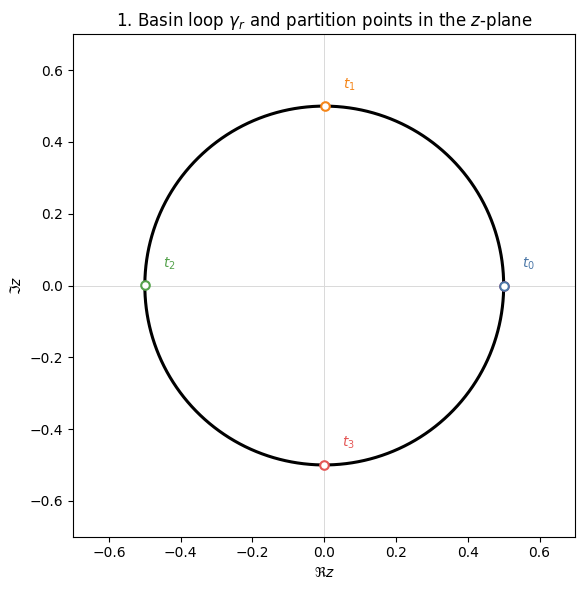

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.set_aspect('equal')
ax.plot(z_curve.real, z_curve.imag, color='black', lw=2.2)
ax.scatter([z_curve[0].real], [z_curve[0].imag], color='crimson', s=42, zorder=4)
for j, p in enumerate(partition_points_z):
    ax.scatter([p.real], [p.imag], color='white', edgecolor=colors[j], s=38, zorder=5, linewidth=1.5)
    ax.text(p.real + 0.05, p.imag + 0.05, rf'$t_{j}$', color=colors[j], fontsize=10)
ax.axhline(0, color='0.85', lw=0.7)
ax.axvline(0, color='0.85', lw=0.7)
ax.set_xlim(-0.7, 0.7)
ax.set_ylim(-0.7, 0.7)
ax.set_title(r'1. Basin loop $\gamma_r$ and partition points in the $z$-plane')
ax.set_xlabel(r'$\Re z$')
ax.set_ylabel(r'$\Im z$')
plt.tight_layout()
plt.show()


#### 1. Basin loop in the $z$-plane

The positive model starts from the actual loop
$$
\gamma_r(t) = \tfrac{1}{2} e^{2\pi i t}.
$$
The colored points are the partition points $t_0,t_1,t_2,t_3$ used in the weakened theorem. They determine the four subarcs whose images will be covered by the chart domains $U_0,U_1,U_2,U_3$.


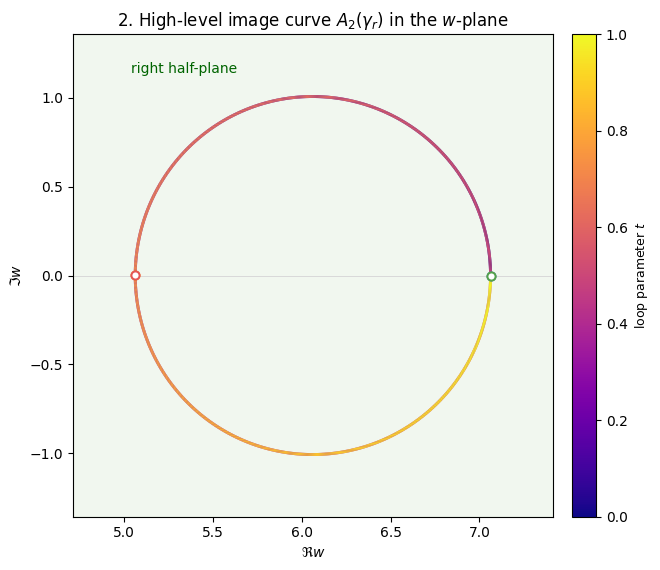

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 5.8))
pts = np.column_stack([w_curve.real, w_curve.imag]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='plasma', lw=2.1, norm=plt.Normalize(0, 1))
lc.set_array(t[:-1])
ax.add_collection(lc)
ax.axvspan(0, w_curve.real.max() + 0.5, color='#d9ead3', alpha=0.35)
ax.axvline(0, color='0.5', lw=1.2, ls='--')
ax.text(0.12, 0.92, r'right half-plane', transform=ax.transAxes, color='darkgreen', fontsize=10)
for j, p in enumerate(partition_points_w):
    ax.scatter([p.real], [p.imag], color='white', edgecolor=colors[j], s=34, zorder=5, linewidth=1.4)
ax.set_xlim(w_curve.real.min() - 0.35, w_curve.real.max() + 0.35)
ax.set_ylim(w_curve.imag.min() - 0.35, w_curve.imag.max() + 0.35)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='0.85', lw=0.7)
ax.set_title(r'2. High-level image curve $A_2(\gamma_r)$ in the $w$-plane')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
cb = plt.colorbar(lc, ax=ax, fraction=0.045, pad=0.03)
cb.set_label(r'loop parameter $t$', fontsize=9)
plt.tight_layout()
plt.show()


#### 2. High-level image curve in the $w$-plane

Applying
$$
A_2(z)=z^4+4z^2+6
$$
to the loop produces the high-level image curve
$$
A_2(\gamma_r([0,1])) \subset \mathbf{C} \setminus \{0\}.
$$
In this example the whole curve lies in the right half-plane, so it has winding number $0$ around $0$. This is why the example is a positive case: the principal logarithm can be used locally on every chart.


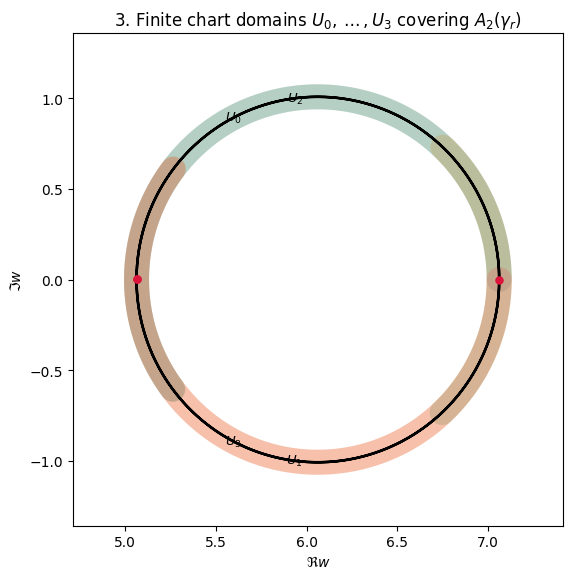

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.9))
for j, ((a, b), color) in enumerate(zip(interval_bounds, colors)):
    seg = w_curve[a:b + 1]
    ax.plot(seg.real, seg.imag, color=color, lw=18, alpha=0.24, solid_capstyle='round')
    mid = w_curve[(a + b) // 2]
    ax.text(mid.real, mid.imag, rf'$U_{j}$', fontsize=9.5, ha='center', va='center')
ax.plot(w_curve.real, w_curve.imag, color='black', lw=1.8)
for p in break_points_w:
    ax.scatter([p.real], [p.imag], color='crimson', s=26, zorder=5)
ax.axvline(0, color='0.8', lw=0.8, ls='--')
ax.set_xlim(w_curve.real.min() - 0.35, w_curve.real.max() + 0.35)
ax.set_ylim(w_curve.imag.min() - 0.35, w_curve.imag.max() + 0.35)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'3. Finite chart domains $U_0,\dots,U_3$ covering $A_2(\gamma_r)$')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
plt.tight_layout()
plt.show()


#### 3. Finite chart domains $U_j$ in the $w$-plane

The colored tubular regions are the simply connected zero-free chart domains
$$
U_0, U_1, U_2, U_3 \subset \mathbf{C} \setminus \{0\}
$$
from the weakened theorem. Each subarc
$$
A_2([t_j,t_{j+1}])
$$
is contained in the corresponding chart $U_j$. The red points mark the breakpoints where adjacent charts must be compared.


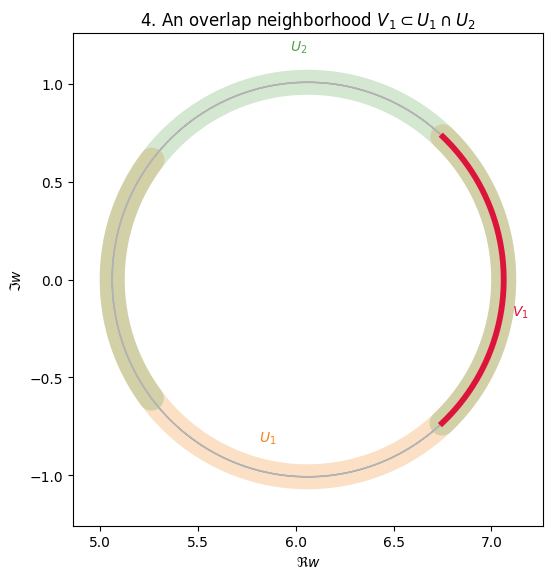

In [6]:
k = 1
fig, ax = plt.subplots(figsize=(7.3, 5.9))
mask_left = interval_masks[k]
mask_right = interval_masks[k + 1]
mask_overlap = overlap_masks[k]

ax.plot(w_curve[mask_left].real, w_curve[mask_left].imag, color=colors[k], lw=18, alpha=0.25, solid_capstyle='round')
ax.plot(w_curve[mask_right].real, w_curve[mask_right].imag, color=colors[k + 1], lw=18, alpha=0.25, solid_capstyle='round')
ax.plot(w_curve.real, w_curve.imag, color='0.7', lw=1.1)
ax.plot(w_curve[mask_overlap].real, w_curve[mask_overlap].imag, color='crimson', lw=4.2)
mid_left = w_curve[np.where(mask_left)[0][len(np.where(mask_left)[0]) // 2]]
mid_right = w_curve[np.where(mask_right)[0][len(np.where(mask_right)[0]) // 2]]
mid_overlap = w_curve[np.where(mask_overlap)[0][len(np.where(mask_overlap)[0]) // 2]]
ax.text(mid_left.real - 0.12, mid_left.imag + 0.17, r'$U_1$', color=colors[k], fontsize=10)
ax.text(mid_right.real + 0.03, mid_right.imag + 0.17, r'$U_2$', color=colors[k + 1], fontsize=10)
ax.text(mid_overlap.real + 0.04, mid_overlap.imag - 0.18, r'$V_1$', color='crimson', fontsize=10)
ax.axvline(0, color='0.8', lw=0.8, ls='--')
ax.set_xlim(w_curve.real.min() - 0.2, w_curve.real.max() + 0.2)
ax.set_ylim(w_curve.imag.min() - 0.25, w_curve.imag.max() + 0.25)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'4. An overlap neighborhood $V_1 \subset U_1 \cap U_2$')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
plt.tight_layout()
plt.show()


#### 4. Overlap neighborhoods $V_j$

The crimson arc models the overlap neighborhood
$$
V_1 \subset U_1 \cap U_2.
$$
This is the theorem-critical location. The weakened theorem asks for the neighboring local logarithm branches to agree on such a neighborhood. In the present positive example they do, because both branches are simply restrictions of the principal logarithm on the right half-plane.


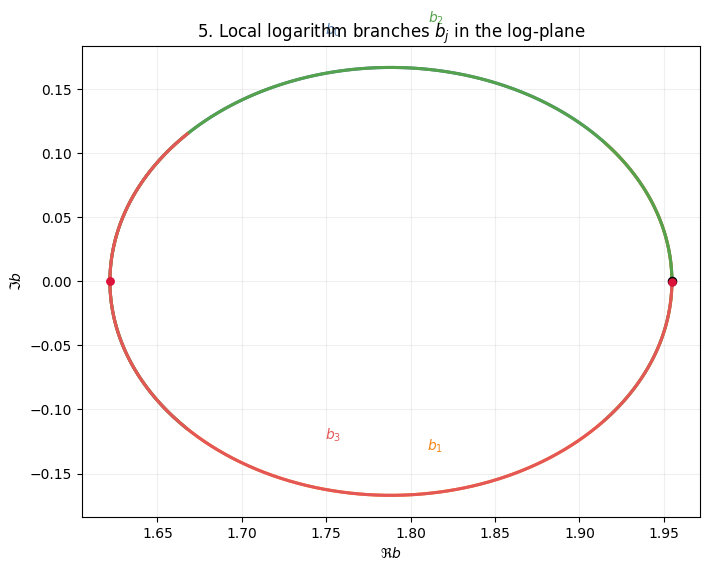

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.8))
for j, (mask, color) in enumerate(zip(interval_masks, colors)):
    vals = b_curve[mask]
    ax.plot(vals.real, vals.imag, color=color, lw=2.2)
    mid = vals[len(vals) // 2]
    ax.text(mid.real + 0.015, mid.imag + 0.035, rf'$b_{j}$', color=color, fontsize=10)
ax.scatter([b_curve[0].real], [b_curve[0].imag], color='black', s=35, zorder=5)
for p in break_points_log:
    ax.scatter([p.real], [p.imag], color='crimson', s=26, zorder=5)
ax.set_xlabel(r'$\Re b$')
ax.set_ylabel(r'$\Im b$')
ax.set_title(r'5. Local logarithm branches $b_j$ in the log-plane')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### 5. Local logarithm branches $b_j$

The log-plane picture shows the local logarithm branches
$$
b_j : U_j \to \mathbf{C}
$$
from the weakened theorem. In this positive example,
$$
b_j = \log|_{U_j}
$$
for every $j$, so the four colored pieces fit together into one smooth curve in the log-plane. The red points are the images of the breakpoints, where the equality
$$
b_{j+1} = b_j \quad \text{on } V_j
$$
is read off.


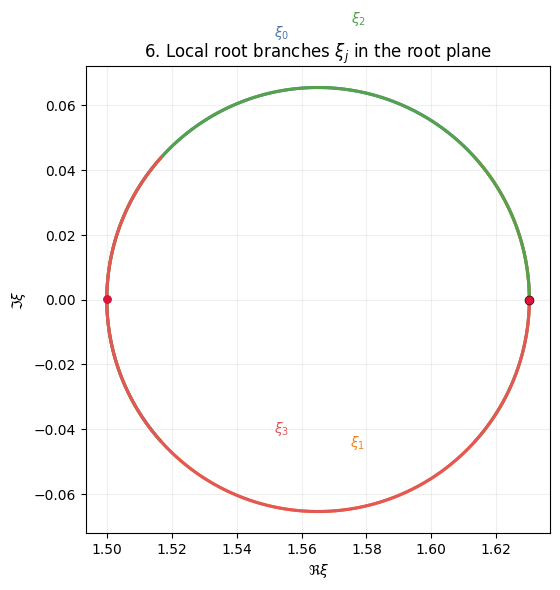

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 6.0))
for j, (mask, color) in enumerate(zip(interval_masks, colors)):
    vals = xi_curve[mask]
    ax.plot(vals.real, vals.imag, color=color, lw=2.2)
    mid = vals[len(vals) // 2]
    ax.text(mid.real + 0.01, mid.imag + 0.02, rf'$\xi_{j}$', color=color, fontsize=10)
ax.scatter([xi_curve[0].real], [xi_curve[0].imag], color='black', s=35, zorder=5)
for p in break_points_xi:
    ax.scatter([p.real], [p.imag], color='crimson', s=26, zorder=5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$\Re \xi$')
ax.set_ylabel(r'$\Im \xi$')
ax.set_title(r'6. Local root branches $\xi_j$ in the root plane')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### 6. Local root branches $\xi_j$

The root-plane picture shows the local branches
$$
\xi_j(w) = \exp\!\left(\frac{1}{4} b_j(w)\right),
$$
which satisfy
$$
\xi_j(w)^4 = w
$$
on each chart $U_j$. Since the logarithm branches agree on every overlap neighborhood $V_j$, the local root branches agree there as well:
$$
\xi_{j+1} = \xi_j \quad \text{on } V_j.
$$
This is exactly the overlap-equality content that the weakened theorem needs.


### Generalized proof outline following the geometric construction

The positive model above displays every object appearing in the weakened theorem.

| Positive-model object | General theorem object | Role in the weakened theorem |
|---|---|---|
| the small basin loop $\gamma_r$ in the $z$-plane | a basin loop $\gamma$ based at $z_0$ | the path along which the actual branches are continued |
| the curve $A_2(\gamma_r)$ in the $w$-plane | the high-level image curve $A_K \circ \gamma$ | the compact curve to be covered by local charts |
| the colored tubular neighborhoods $U_0,\dots,U_3$ | the chart domains $U_j$ | simply connected zero-free domains carrying local logarithms |
| the crimson overlap arc $V_1$ | the overlap neighborhoods $V_j$ | the places where neighboring branches must be shown equal |
| the colored log-plane pieces $b_j$ | the local logarithm branches $b_j$ | the branch data whose overlap equality is the actual theorem hypothesis |
| the colored root-plane pieces $\xi_j$ | the local root branches $\xi_j$ | the branch data that enter the chart-chain monodromy comparison |

#### Proof skeleton

1. choose a sufficiently high escaping level $K$ for the given loop;
2. cover the image curve $A_K(\gamma([0,1]))$ by finitely many simply connected zero-free charts $U_j$;
3. define on each chart the actual local logarithm branch $b_j$ and the induced local root branch $\xi_j$ from the normalized starting germ;
4. prove that on each overlap neighborhood $V_j$ the neighboring branches satisfy
   $$
   b_{j+1} = b_j
   \qquad \text{and hence} \qquad
   \xi_{j+1} = \xi_j;
   $$
5. package these data as the mathematical content of `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`, and then apply the already formalized theorem
   `ChartChainLocalLogsEventuallyEqAtOverlaps.monodromyProduct_eq_one`.

The large-circle counterexample shows why Step 4 must be stated **locally on the overlap neighborhoods $V_j$** rather than by demanding one global logarithm domain for the whole loop image.


### Rigorous proof in the weakened setting

The proof skeleton above can be stated as the following exact local theorem.

**Theorem (trivial monodromy from weakened local chart-chain data).**
Let
$$
\gamma : [0,1] \to \operatorname{basin}_\infty(2)
$$
be a basin loop, let $K \in \mathbf{N}$, let
$$
0=t_0<t_1<\cdots<t_{m+1}=1
$$
be a partition, and let
$$
A_K(t)=\text{logSeriesBottcherApprox}\bigl(2,f_2^K(\gamma(t))\bigr).
$$
Assume there are connected simply connected open sets
$$
U_0,\dots,U_m\subset \mathbf{C}\setminus\{0\},
$$
connected nonempty open sets
$$
V_j\subset U_j\cap U_{j+1}\qquad(0\leq j<m),
$$
and holomorphic functions
$$
b_j:U_j\to\mathbf{C},\qquad \xi_j:U_j\to\mathbf{C}\qquad(0\leq j\leq m)
$$
such that:

1. for every $0\leq j\leq m$,
   $$
   A_K([t_j,t_{j+1}])\subset U_j;
   $$
2. for every $0\leq j<m$ there exists $\varepsilon_j>0$ with
   $$
   A_K([t_{j+1}-\varepsilon_j,\,t_{j+1}+\varepsilon_j])\subset V_j;
   $$
3. for every $0\leq j\leq m$ and every $w\in U_j$,
   $$
   e^{b_j(w)}=w;
   $$
4. for every $0\leq j\leq m$ and every $w\in U_j$,
   $$
   \xi_j(w)=\exp\!\left(\frac{1}{2^K}b_j(w)\right);
   $$
5. for every $0\leq j<m$,
   $$
   b_{j+1}=b_j\quad\text{on }V_j.
   $$

Then:

1. for every $0\leq j<m$,
   $$
   \xi_{j+1}=\xi_j\quad\text{on }V_j;
   $$
2. if $\zeta_j\in\mu_{2^K}$ is the adjacent overlap multiplier defined by
   $$
   \xi_{j+1}(w)=\zeta_j\,\xi_j(w)
   \qquad (w\in V_j),
   $$
   then
   $$
   \zeta_j=1\qquad(0\leq j<m);
   $$
3. consequently the monodromy product satisfies
   $$
   \prod_{j=0}^{m-1}\zeta_j=1.
   $$

**Proof.**
Fix $j$ with $0\leq j<m$. Since $b_{j+1}=b_j$ on $V_j$, for every $w\in V_j$ we have
$$
\xi_{j+1}(w)
= \exp\!\left(\frac{1}{2^K}b_{j+1}(w)\right)
= \exp\!\left(\frac{1}{2^K}b_j(w)\right)
= \xi_j(w).
$$
This proves the first claim.

Now let $\zeta_j\in\mu_{2^K}$ be an overlap multiplier with
$$
\xi_{j+1}(w)=\zeta_j\,\xi_j(w)
\qquad (w\in V_j).
$$
Because $\xi_{j+1}=\xi_j$ on $V_j$, we obtain
$$
\zeta_j\,\xi_j(w)=\xi_j(w)
\qquad (w\in V_j).
$$
The function $\xi_j$ never vanishes on $V_j$, since
$$
\xi_j(w)^{2^K}=w
$$
and $V_j\subset \mathbf{C}\setminus\{0\}$. Therefore division by $\xi_j(w)$ gives
$$
\zeta_j=1.
$$
This proves the second claim. The third claim follows immediately by multiplying the identities $\zeta_j=1$ over all adjacent overlaps. $\square$

**Interpretation for Step 13.** The proof above is now formalized in Lean at the abstract chart-chain level. The direct open-set route is packaged by `ZeroFreeChartRootBranchData.rootBranch_eqOn_of_logBranch_eqOn`, `BasinLoopChartOverlapStep.multiplier_eq_one_of_eqOn`, `ChartChainLocalLogsEventuallyEqAtOverlaps.of_open_eqOn`, and `BasinLoopChartChain.monodromyProduct_eq_one_of_open_eqOn`. So the only genuinely difficult remaining part is to construct the actual domains $U_j$, overlap neighborhoods $V_j$, and branches $b_j,\xi_j$ for the genuine high-escaping chains.


## Lean target isolated by this notebook

The general Step 13 target is still to build the data consumed by

```lean
HighEscapingActualChartChainsEventuallyEqAtOverlapsData
```

for the genuine high-escaping chart chains at $c = 2$. The abstract local theorem isolated by this notebook is now formalized: open overlap equality of the logarithm branches already implies trivial overlap multipliers and trivial chart-chain monodromy. So Step 13 no longer needs a new monodromy theorem; it needs the actual chart data that feed that theorem.

The notebook now records both sides of that statement:

- the counterexample explains why one may **not** replace the theorem by a universal global-log package;
- the positive model shows exactly what the weakened theorem must produce in a good case: charts $U_j$, overlap neighborhoods $V_j$, local logarithms $b_j$, local roots $\xi_j$, and local equalities on the overlaps;
- the remaining proof gap is to construct and package those objects for the genuine high-escaping chains, first as `HighEscapingActualChartChainsEventuallyEqAtOverlapsData` and then as `HighEscapingActualChartChainsProductComparisonData`.

The stronger package

```lean
HighEscapingActualChartChainsLocalLogsRestrictGlobalData
```

remains available as a special case when one global logarithm domain does exist, but it is no longer the theorem to pursue in general.
